# Implementing Yann LeCun's LeNet-5 in PyTorch

The code bellow comes from https://github.com/erykml/medium_articles/blob/master/Computer%20Vision/lenet5_pytorch.ipynb.<br>
Last update: August 5, 2022

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1TZKpcQBlQrEWZgfrFy42x05eIjl466Bn?usp=sharing)

## Setup

In [1]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [9]:
import numpy as np
from datetime import datetime 

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

import matplotlib.pyplot as plt

# check device
# DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

/Users/boisalai/opt/anaconda3/envs/ml/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
# Select 'ML' kernel.
DEVICE = 'mps'

In [2]:
%config InlineBackend.figure_format = 'retina'

In [3]:
# parameters
RANDOM_SEED = 42
LEARNING_RATE = 0.001
BATCH_SIZE = 32
N_EPOCHS = 15

IMG_SIZE = 32
N_CLASSES = 10

## Helper Functions

In [10]:
def get_accuracy(model, data_loader, device):
    '''
    Function for computing the accuracy of the predictions over the entire data_loader
    '''
    
    correct_pred = 0 
    n = 0
    
    with torch.no_grad():
        model.eval()
        for X, y_true in data_loader:

            X = X.to(device)
            y_true = y_true.to(device)

            _, y_prob = model(X)
            _, predicted_labels = torch.max(y_prob, 1)

            n += y_true.size(0)
            correct_pred += (predicted_labels == y_true).sum()

    return correct_pred.float() / n

def plot_losses(train_losses, valid_losses):
    '''
    Function for plotting training and validation losses
    '''
    
    # temporarily change the style of the plots to seaborn 
    plt.style.use('seaborn')

    train_losses = np.array(train_losses) 
    valid_losses = np.array(valid_losses)

    fig, ax = plt.subplots(figsize = (8, 4.5))

    ax.plot(train_losses, color='blue', label='Training loss') 
    ax.plot(valid_losses, color='red', label='Validation loss')
    ax.set(title="Loss over epochs", 
            xlabel='Epoch',
            ylabel='Loss') 
    ax.legend()
    fig.show()
    
    # change the plot style to default
    plt.style.use('default')

In [11]:
def train(train_loader, model, criterion, optimizer, device):
    '''Function for the training step of the training loop'''
    model.train()
    running_loss = 0
    
    for X, y_true in train_loader:

        optimizer.zero_grad()
        
        X = X.to(device)
        y_true = y_true.to(device)
    
        # Forward pass
        y_hat, _ = model(X) 
        loss = criterion(y_hat, y_true) 
        running_loss += loss.item() * X.size(0)

        # Backward pass
        loss.backward()
        optimizer.step()
        
    epoch_loss = running_loss / len(train_loader.dataset)
    return model, optimizer, epoch_loss

In [12]:
def validate(valid_loader, model, criterion, device):
    '''Function for the validation step of the training loop'''
    model.eval()
    running_loss = 0
    
    for X, y_true in valid_loader:
    
        X = X.to(device)
        y_true = y_true.to(device)

        # Forward pass and record loss
        y_hat, _ = model(X) 
        loss = criterion(y_hat, y_true) 
        running_loss += loss.item() * X.size(0)

    epoch_loss = running_loss / len(valid_loader.dataset)
        
    return model, epoch_loss

In [13]:
def training_loop(model, criterion, optimizer, train_loader, valid_loader, epochs, device, print_every=1):
    '''Function defining the entire training loop'''
    # set objects for storing metrics
    best_loss = 1e10
    train_losses = []
    valid_losses = []
 
    # Train model
    for epoch in range(0, epochs):

        # training
        model, optimizer, train_loss = train(train_loader, model, criterion, optimizer, device)
        train_losses.append(train_loss)

        # validation
        with torch.no_grad():
            model, valid_loss = validate(valid_loader, model, criterion, device)
            valid_losses.append(valid_loss)

        if epoch % print_every == (print_every - 1):
            
            train_acc = get_accuracy(model, train_loader, device=device)
            valid_acc = get_accuracy(model, valid_loader, device=device)
                
            print(f'{datetime.now().time().replace(microsecond=0)} --- '
                  f'Epoch: {epoch}\t'
                  f'Train loss: {train_loss:.4f}\t'
                  f'Valid loss: {valid_loss:.4f}\t'
                  f'Train accuracy: {100 * train_acc:.2f}\t'
                  f'Valid accuracy: {100 * valid_acc:.2f}')

    plot_losses(train_losses, valid_losses)
    
    return model, optimizer, (train_losses, valid_losses)

## Data

In [14]:
# define transforms
# transforms.ToTensor() automatically scales the images to [0,1] range
transforms = transforms.Compose([transforms.Resize((32, 32)),
                                 transforms.ToTensor()])

# download and create datasets
train_dataset = datasets.MNIST(root='mnist_data', 
                               train=True, 
                               transform=transforms,
                               download=True)

valid_dataset = datasets.MNIST(root='mnist_data', 
                               train=False, 
                               transform=transforms)

# define the data loaders
train_loader = DataLoader(dataset=train_dataset, 
                          batch_size=BATCH_SIZE, 
                          shuffle=True)

valid_loader = DataLoader(dataset=valid_dataset, 
                          batch_size=BATCH_SIZE, 
                          shuffle=False)

100%|████████████████████████████| 9912422/9912422 [00:01<00:00, 8841274.09it/s]


Extracting mnist_data/MNIST/raw/train-images-idx3-ubyte.gz to mnist_data/MNIST/raw



100%|███████████████████████████████| 28881/28881 [00:00<00:00, 10781033.63it/s]


Extracting mnist_data/MNIST/raw/train-labels-idx1-ubyte.gz to mnist_data/MNIST/raw



100%|████████████████████████████| 1648877/1648877 [00:00<00:00, 6856493.59it/s]


Extracting mnist_data/MNIST/raw/t10k-images-idx3-ubyte.gz to mnist_data/MNIST/raw



100%|██████████████████████████████████| 4542/4542 [00:00<00:00, 4321807.80it/s]

Extracting mnist_data/MNIST/raw/t10k-labels-idx1-ubyte.gz to mnist_data/MNIST/raw



### Plotting the images

In [15]:
ROW_IMG = 10
N_ROWS = 5

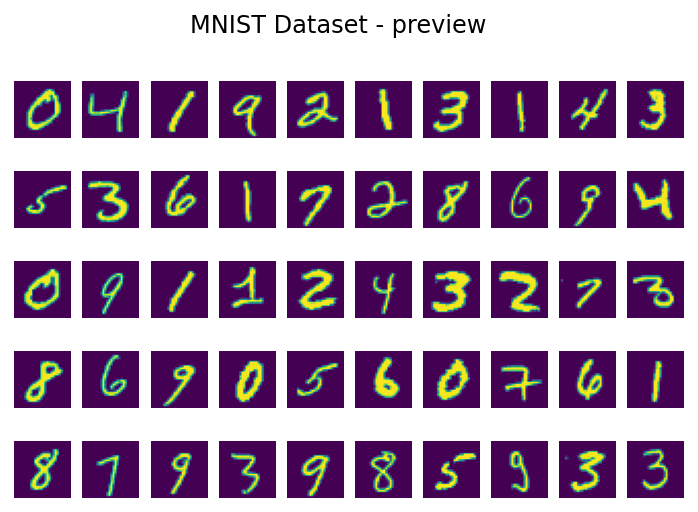

In [16]:
fig = plt.figure()
for index in range(1, ROW_IMG * N_ROWS + 1):
    plt.subplot(N_ROWS, ROW_IMG, index)
    plt.axis('off')
    plt.imshow(train_dataset.data[index])
fig.suptitle('MNIST Dataset - preview');

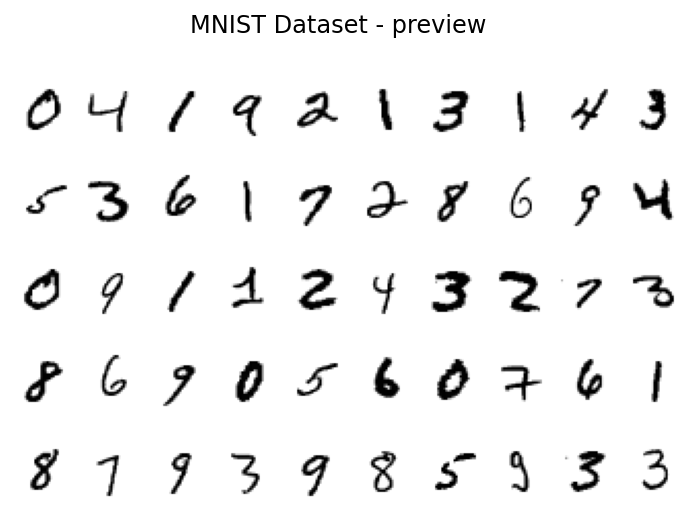

In [17]:
fig = plt.figure()
for index in range(1, ROW_IMG * N_ROWS + 1):
    plt.subplot(N_ROWS, ROW_IMG, index)
    plt.axis('off')
    plt.imshow(train_dataset.data[index], cmap='gray_r')
fig.suptitle('MNIST Dataset - preview');

## Implementing LeNet-5

J'ai ajusté l'implémentation pour utiliser `sigmoid` au lieu de `tahn`. Voir https://en.wikipedia.org/wiki/LeNet.

Je crois que l'auteur a utilisé `tahn` qui performerait mieux que `sigmoid`. 

> **Is tanh better than sigmoid?**<br>
`tanh` function is symmetric about the origin, where the inputs would be normalized and they are more likely to produce outputs (which are inputs to next layer)and also, they are on an average close to zero. ... These are the main reasons why tanh is preferred and performs better than sigmoid (logistic).<br>https://medium.com/analytics-vidhya/activation-functions-why-tanh-outperforms-logistic-sigmoid-3f26469ac0d1|



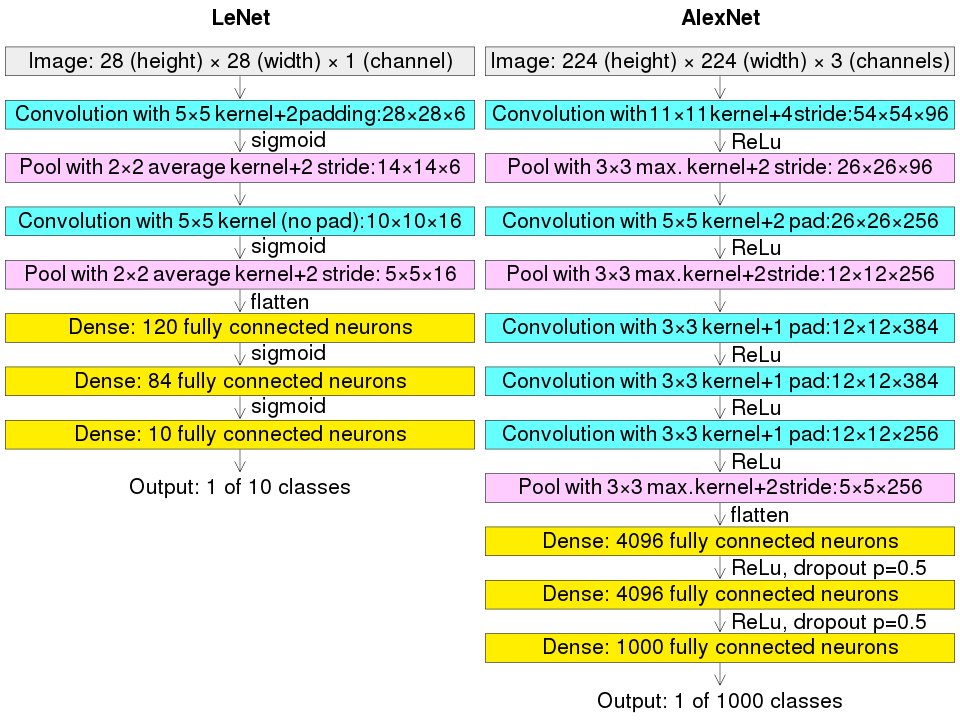

In [18]:
class LeNet5(nn.Module):
  def __init__(self, n_classes):
    super(LeNet5, self).__init__()

    # With Sigmoid()
    self.feature_extractor = nn.Sequential(
      nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1),
      nn.Sigmoid(),
      nn.AvgPool2d(kernel_size=2),
      nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1),
      nn.Sigmoid(),
      nn.AvgPool2d(kernel_size=2),
      nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1),
      nn.Sigmoid()
    )

    self.classifier = nn.Sequential(
      nn.Linear(in_features=120, out_features=84),
      nn.Sigmoid(),
      nn.Linear(in_features=84, out_features=n_classes),
    )

  def forward(self, x):
    x = self.feature_extractor(x)
    x = torch.flatten(x, 1)
    logits = self.classifier(x)
    probs = F.softmax(logits, dim=1)
    return logits, probs

In [19]:
torch.manual_seed(RANDOM_SEED)

model = LeNet5(N_CLASSES).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

14:56:11 --- Epoch: 0	Train loss: 0.7435	Valid loss: 0.2189	Train accuracy: 93.37	Valid accuracy: 93.67
14:56:30 --- Epoch: 1	Train loss: 0.1765	Valid loss: 0.1263	Train accuracy: 96.22	Valid accuracy: 96.19
14:56:49 --- Epoch: 2	Train loss: 0.1121	Valid loss: 0.0923	Train accuracy: 97.00	Valid accuracy: 97.11
14:57:07 --- Epoch: 3	Train loss: 0.0844	Valid loss: 0.0638	Train accuracy: 98.02	Valid accuracy: 98.06
14:57:27 --- Epoch: 4	Train loss: 0.0689	Valid loss: 0.0658	Train accuracy: 97.91	Valid accuracy: 98.01
14:57:46 --- Epoch: 5	Train loss: 0.0581	Valid loss: 0.0583	Train accuracy: 98.44	Valid accuracy: 98.09
14:58:06 --- Epoch: 6	Train loss: 0.0492	Valid loss: 0.0518	Train accuracy: 98.66	Valid accuracy: 98.35
14:58:24 --- Epoch: 7	Train loss: 0.0443	Valid loss: 0.0416	Train accuracy: 98.99	Valid accuracy: 98.65
14:58:43 --- Epoch: 8	Train loss: 0.0385	Valid loss: 0.0457	Train accuracy: 98.89	Valid accuracy: 98.55
14:59:02 --- Epoch: 9	Train loss: 0.0342	Valid loss: 0.0432	Trai

/var/folders/d_/71qkpq1n5zn9lq_6v8j8hgkr0000gn/T/ipykernel_30957/2211512462.py:43: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


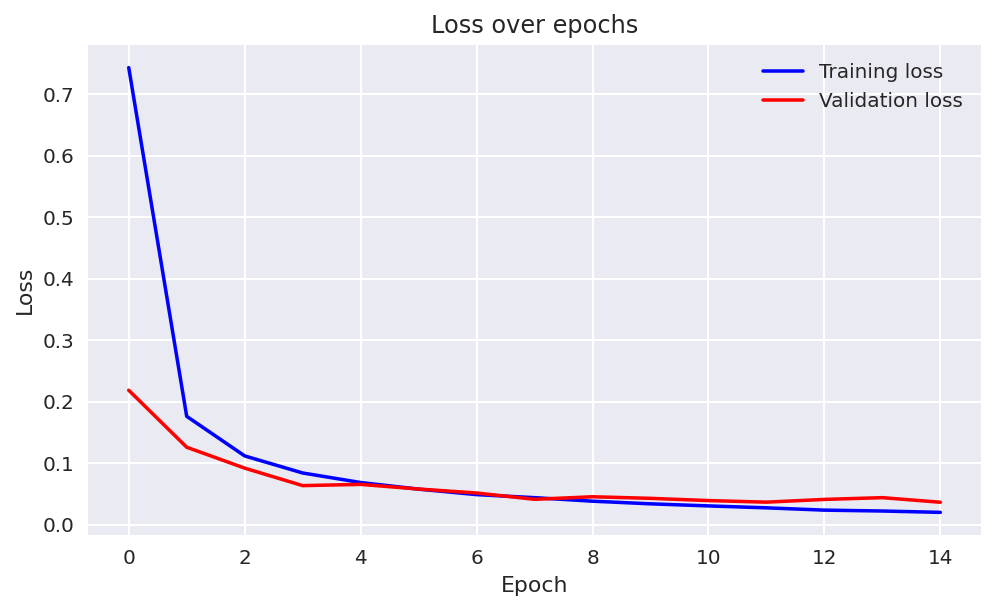

In [20]:
model, optimizer, _ = training_loop(model, criterion, optimizer, train_loader, valid_loader, N_EPOCHS, DEVICE)

## Evaluating the predictions

J'ai corrigé le code en ajoutant `.to(DEVICE)` à l'instruction `_, probs = model(valid_dataset[index][0].to(DEVICE).unsqueeze(0))`.

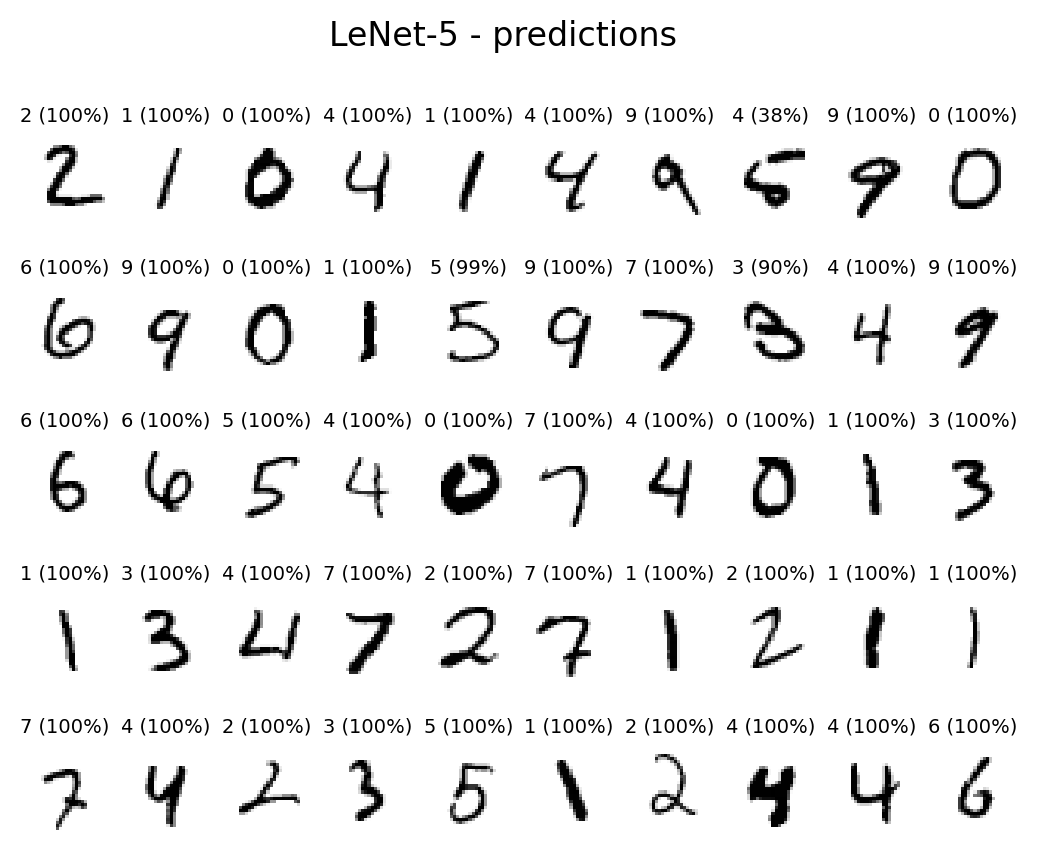

In [21]:
ROW_IMG = 10
N_ROWS = 5

fig = plt.figure()
for index in range(1, ROW_IMG * N_ROWS + 1):
    plt.subplot(N_ROWS, ROW_IMG, index)
    plt.axis('off')
    plt.imshow(valid_dataset.data[index], cmap='gray_r')
    
    with torch.no_grad():
        model.eval()
        # _, probs = model(valid_dataset[index][0].unsqueeze(0))
        # RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same`
        _, probs = model(valid_dataset[index][0].to(DEVICE).unsqueeze(0))
        
    title = f'{torch.argmax(probs)} ({torch.max(probs * 100):.0f}%)'
    
    plt.title(title, fontsize=7)
fig.suptitle('LeNet-5 - predictions');

In [23]:
# remove the downloaded dataset
!rm -r mnist_data

rm: mnist_data: No such file or directory
